In [139]:
import numpy as np
import cupy as cp

class Softmax:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        exp_x = cp.exp(x - cp.max(x, axis=1, keepdims=True))
        return exp_x / cp.sum(exp_x, axis=1, keepdims=True)

class Sigmoid:
    # Xavier initialization
    weight_init_factor = 1.

    def forward(self, x):
        return 1 / (1 + cp.exp(-x))
    
    def derivative(self, x):
        s = self.forward(x)
        return s * (1 - s)

class ReLU:
    # He initialization
    weight_init_factor = cp.sqrt(2)

    def forward(self, x):
        return cp.maximum(0, x)
    
    def derivative(self, x):
        return (x > 0).astype(float)

class Linear:
    # Xavier initialization
    weight_init_factor = 1.0

    def forward(self, x):
        return x

    def derivative(self, x):
        return cp.ones_like(x)

In [140]:
class Layer:
    def __init__(self, num_neurons: int, num_input_connections: int, activation_function, rng, alpha=0.05, beta_one=0.9, beta_two=0.999, epsilon = 1e-8):
        self.num_neurons = num_neurons
        self.activation_function = activation_function
        self.weights =  cp.asarray(rng.standard_normal((num_input_connections, num_neurons))) * activation_function.weight_init_factor * cp.sqrt(1/num_input_connections)
        self.biases = cp.asarray(rng.standard_normal(num_neurons) * 0.01)
        self.prev_inputs = None
        self.z = None
        self.error_signals = None
        self.alpha = alpha


        # adam optimizer stuff
        self.ma_weight_signal = cp.zeros((num_input_connections, num_neurons)) # moving average bias gradient signal for adam optimizer
        self.ma_bias_signal = cp.zeros(num_neurons) # moving average weight gradient signal for adam optimizer
        self.update_steps = 0
        self.beta_one = beta_one
        self.ma_weight_signal_variance = cp.zeros((num_input_connections, num_neurons))
        self.ma_bias_signal_variance = cp.zeros(num_neurons)
        self.beta_two = beta_two
        self.epsilon = epsilon

    def forward(self, x) -> cp.array:
        self.z = x @ self.weights + self.biases
        self.prev_inputs = x
        return self.activation_function.forward(self.z)

    def backward(self, error_signals) -> np.array:
        self.update_steps += 1

        # i didnt add a derivative to softmax cus im lazy, i didn't feel like spending the time figuring out the jacobians, just passing the loss for the next step all the way through
        if hasattr(self.activation_function, 'derivative'):
            dLdz = error_signals * self.activation_function.derivative(self.z)
        else:
            dLdz = error_signals
    
        batch_size = error_signals.shape[0]

        bias_gradient_signal = cp.sum(dLdz, axis=0) / batch_size
        self.ma_bias_signal = (self.beta_one * self.ma_bias_signal) + (1 - self.beta_one) * bias_gradient_signal # first moment
        self.ma_bias_signal_variance = (self.beta_two * self.ma_bias_signal_variance) + (1 - self.beta_two) * bias_gradient_signal ** 2 # second moment
        mb = self.ma_bias_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vb = self.ma_bias_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dB = mb / (cp.sqrt(vb) + self.epsilon)

        weight_gradient_signal = (self.prev_inputs.T @ dLdz) / batch_size
        self.ma_weight_signal = ( (self.beta_one * self.ma_weight_signal) + (1 - self.beta_one) * weight_gradient_signal ) # first moment
        self.ma_weight_signal_variance = (self.beta_two * self.ma_weight_signal_variance) + (1 - self.beta_two) * weight_gradient_signal ** 2 # second moment
        mw = self.ma_weight_signal / (1 - self.beta_one ** self.update_steps) # bias correction
        vw = self.ma_weight_signal_variance / (1 - self.beta_two ** self.update_steps) # bias correction
        dW = mw / (cp.sqrt(vw) + self.epsilon)

        error_signals = dLdz @ self.weights.T
        self.biases += -self.alpha * dB
        self.weights += -self.alpha * dW

        return error_signals

In [141]:
import numpy as np


def load_model(layers, filepath="sparse_mnist.npz"):
    data = np.load(filepath)
    for i, layer in enumerate(layers):
        layer.weights = cp.asarray(data[f"w_{i}"])
        layer.biases = cp.asarray(data[f"b_{i}"])


pretrained_classifier = [
    Layer(num_neurons=256, num_input_connections=784, activation_function=ReLU(), rng=np.random.default_rng(), alpha=0.0003),
    Layer(num_neurons=256, num_input_connections=256, activation_function=ReLU(), rng=np.random.default_rng(), alpha=0.0003),
    Layer(num_neurons=10, num_input_connections=256, activation_function=Softmax(), rng=np.random.default_rng(), alpha=0.0003)
]

load_model(pretrained_classifier, "sparse_mnist.npz")

In [142]:
%matplotlib inline
import matplotlib.pyplot as plt
from os.path import join
import struct

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = np.frombuffer(file.read(), dtype=np.uint8)
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            images = np.frombuffer(file.read(), dtype=np.uint8).reshape(size, rows, cols)
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)

#
# Set file paths based on added MNIST Datasets
#
input_path = ''
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()


x_train = np.array([x.ravel() for x in x_train], dtype=np.float32) / 255.0
x_test = np.array([x.ravel() for x in x_test], dtype=np.float32) / 255.0

x_train = cp.asarray(x_train)
x_test  = cp.asarray(x_test)
y_train = cp.asarray(y_train)
y_test = cp.asarray(y_test)

def get_batches(X, y, batch_size):
    num_samples = X.shape[0]
    indices = cp.arange(num_samples)
    
    cp.random.shuffle(indices)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        
        yield X[batch_indices], y[batch_indices]

print(x_train.shape)
print(x_test.shape)



(60000, 784)
(10000, 784)


In [143]:
rng = cp.random.default_rng(42)


buffer_capacity = 100_000
state_size = 784 + 784 + 1   # 784 values for the current observed values of all states, 
                             # 784 values in the mask (which pixels we currently have access to), 
                             # and 1 pixel for the remaining budget of pixel reveals left)
num_pixel_reveals = 60
epsilon = 0.9 # for epsilon greedy search

class Network():
    def __init__(self):
        self.layers = [
            Layer(num_neurons=256, num_input_connections=state_size, activation_function=ReLU(), rng=rng, alpha=0.0003),
            Layer(num_neurons=256, num_input_connections=256, activation_function=ReLU(), rng=rng, alpha=0.0003),
            Layer(num_neurons=784, num_input_connections=256, activation_function=Linear(), rng=rng, alpha=0.0003)
        ]

    def full_forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def full_backward(self, upstream_error):
        for layer in reversed(self.layers):
            upstream_error = layer.backward(upstream_error)
        return upstream_error

    def polyak_average_from(self, online_network: Network, tau: float):
        for i, layer in enumerate(self.layers):
            online_w = online_network.layers[i].weights
            online_b = online_network.layers[i].biases
            
            # exponentially weighted averages
            layer.weights *= (1.0 - tau)
            layer.weights += tau * online_w
            
            layer.biases *= (1.0 - tau)
            layer.biases += tau * online_b

    def copy_weights_from(self, network: Network):
        # not copying any of the adam optimizer stuff bcs this is for the target network so its never doing gradient descent
        for i, layer in enumerate(self.layers):
            layer.weights = network.layers[i].weights.copy()
            layer.biases = network.layers[i].biases.copy()


In [144]:
discount_factor = 0.99
buffer_s = cp.zeros((buffer_capacity, state_size))
buffer_a = cp.zeros(buffer_capacity, dtype=np.int32)
buffer_r = cp.zeros(buffer_capacity)
buffer_s_prime = cp.zeros((buffer_capacity, state_size))
buffer_dones = cp.zeros(buffer_capacity)

buffer_ptr = 0 # points to the index of where weare adding to the buffer
buffer_size = 0 # tracks the current size of the buffer

def reveal_pixel(s, a, secret_images):
    s_copy = s.copy()
    env_indices = cp.arange(s.shape[0])
    s_copy[env_indices, a] = secret_images[env_indices, a]
    s_copy[env_indices, a+784] = 1
    s_copy[env_indices, -1] -= 2 * 1/num_pixel_reveals  # bound from -1 to 1
    return s_copy # replace with revealing one pixel from MNIST image

def get_reward(state, secret_labels):
    out = state[:, :784]
    for layer in pretrained_classifier:
        out = layer.forward(out)
    predictions = cp.argmax(out, axis=1)
    compares = predictions==secret_labels
    return (compares * 2 - 1, cp.mean(compares)) # simple reward +1 if it guesses correctly and -1 if it guesses wrong

def add_to_buffer(s, a, r, s_prime, done):
    global buffer_ptr, buffer_size
    num_samples = s.shape[0]
    indicies = cp.arange(buffer_ptr, buffer_ptr + num_samples) % buffer_capacity

    buffer_s[indicies] = s
    buffer_a[indicies] = a
    buffer_r[indicies] = r
    buffer_s_prime[indicies] = s_prime
    buffer_dones[indicies] = done

    buffer_ptr = (buffer_ptr + num_samples) % buffer_capacity
    buffer_size = min(buffer_size + num_samples, buffer_capacity)

s_buffer = cp.zeros((128, state_size))
def interact(network, num_envs=128):
    global x_train, s_buffer
    s_buffer[:] = 0
    s_buffer[:, -1] = 1.0
    secret_image_indicies = rng.integers(low=0, high=60_000, size=num_envs) # indicies of rnadom integers
    secret_images = x_train[secret_image_indicies]
    secret_labels = y_train[secret_image_indicies]

    avg_reward = 0
    accuracy = 0
    for pixel_reveals_left in range(num_pixel_reveals, 0, -1):
        q_values = network.full_forward(s_buffer) # shape = (num_envs, num actions)
        mask_prev_actions = s_buffer[:, q_values.shape[1] : -1].astype(bool) # mask so the agen't doesn't try to reveal a pixel that it has already revealed
        greedy_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, q_values), axis=1)  # shape = (num_envs,)

        mask_epsilon = rng.random(size=num_envs) < epsilon
        uniform_random = cp.where(mask_prev_actions, -cp.inf, cp.asarray(rng.random((num_envs, 784)))) # mask prev actions for not picking an action we have already took
        random_actions = cp.argmax(uniform_random, axis=1)

        a = cp.where(mask_epsilon, random_actions, greedy_actions) # apply the mask (epsilon greedy search)
        s_prime = reveal_pixel(s_buffer, a, secret_images)

        if pixel_reveals_left == 1:
            s_prime[:, -1] = -1
            reward, accuracy = get_reward(s_prime, secret_labels)
            avg_reward = cp.mean(reward)
            add_to_buffer(s_buffer, a, reward, s_prime, cp.ones(num_envs))
        else:
            add_to_buffer(s_buffer, a, cp.zeros(num_envs), s_prime, cp.zeros(num_envs))
        s_buffer = s_prime
    return avg_reward, accuracy



In [ ]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()
avg_reward = 0
accuracy = 0
huber_loss = 0
mean_q = 0


batch_size = 128

online_network = Network()
target_network = Network()
tau = 0.0005
target_network.copy_weights_from(online_network)

# warm up the buffer
while buffer_size < 20000:
    interact(online_network)

for iteration in range(50000):

    avg_reward, accuracy = interact(online_network) # interacts with the environment and populates the replay buffer

    for _ in range(15): # 15 gradient steps
        indices = cp.random.choice(buffer_size, size=batch_size, replace=False)
        batch_s = buffer_s[indices]
        batch_a = buffer_a[indices]
        batch_r = buffer_r[indices]
        batch_s_prime = buffer_s_prime[indices]
        batch_dones = buffer_dones[indices]

        target_q_prime = target_network.full_forward(batch_s_prime)
        online_best_action = online_network.full_forward(batch_s_prime)
        q_values_s = online_network.full_forward(batch_s)
        q_sa = q_values_s[cp.arange(batch_size), batch_a] # what was the q value for the action we chose
        online_best_action = cp.argmax(cp.where(batch_s_prime[:, 784:-1], -cp.inf, online_best_action), axis=1) # mask target q prime to not include actions we have alr took, then grab the best action

        target_q_prime = target_q_prime[cp.arange(0, batch_size), online_best_action]
        delta =  q_sa - ( batch_r + (1-batch_dones) * discount_factor * target_q_prime )
        quadratic = cp.abs(delta) <= 1
        grad = cp.where(quadratic, delta, cp.sign(delta)) # huber loss bcs the q values were exploding

        huber_loss = cp.mean(cp.where(
            quadratic,
            0.5 * delta**2,
            cp.abs(delta) - 0.5
        ))

        mean_q = cp.mean(q_sa)

        if iteration % 100 == 0 and _ == 14:
            target = (
                batch_r +
                (1-batch_dones) * discount_factor * target_q_prime
            )

            print(f"iteration: {iteration} {float(target.min()),float(target.max()), float(target.mean())}")
            
        # the mlp needs gradients of shape = (batch size, amount of mlp outputs)
        filled_grads = cp.zeros((batch_size, 784))
        filled_grads[cp.arange(batch_size), batch_a] = grad

        online_network.full_backward(filled_grads)
        target_network.polyak_average_from(online_network, tau)


    epsilon = max(0.05, epsilon * 0.9995)
    if iteration % 10000 == 0 and iteration > 0:
        epsilon = max(epsilon, 0.4)

    # logging
    writer.add_scalar("reward", float(avg_reward), iteration)
    writer.add_scalar("accuracy", float(accuracy), iteration)
    writer.add_scalar("loss", float(huber_loss), iteration)
    writer.add_scalar("q_value", float(mean_q), iteration)
    writer.add_scalar("epsilon", float(epsilon), iteration)


iteration: 0 (-1.0, 0.6625792545628907, 0.35225920321616955)
iteration: 100 (-1.0, 1.0, 0.312283149067106)
iteration: 200 (-1.0, 1.0, 0.3561784345361443)
iteration: 300 (0.18382515737412786, 1.0, 0.37847752054250805)
iteration: 400 (-1.0, 1.0, 0.35082873183474045)
iteration: 500 (0.234176682524372, 1.0, 0.35517125222941914)
iteration: 600 (-1.0, 1.0, 0.3349849379404016)
iteration: 700 (-1.0, 1.0, 0.28797359733631855)
iteration: 800 (-1.0, 1.0, 0.28865601697344767)
iteration: 900 (0.15172879789973845, 1.0, 0.2947903299738954)
iteration: 1000 (0.13039650122455237, 1.0, 0.2702374208708762)
iteration: 1100 (0.10835147819993526, 0.46324479185228606, 0.25979105526311647)
iteration: 1200 (-1.0, 1.0, 0.2328850279172894)
iteration: 1300 (-1.0, 0.4300128495256152, 0.1965282957090499)
iteration: 1400 (-1.0, 1.0, 0.23144357435947635)
iteration: 1500 (-1.0, 1.0, 0.24872048141409678)
iteration: 1600 (-1.0, 1.0, 0.2202259104507589)
iteration: 1700 (0.05925503795561584, 1.0, 0.22200461856110856)
itera

KeyboardInterrupt: 

In [ ]:
# %%
def evaluate_policy(network, images, labels, batch_size=256):
    """
    Evaluates the network policy greedily (epsilon=0) across a dataset in batches.
    Returns the classification accuracy as a percentage.
    """
    num_samples = images.shape[0]
    total_correct = 0.0

    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_images = images[start_idx:end_idx]
        batch_labels = labels[start_idx:end_idx]
        curr_batch_size = batch_images.shape[0]

        # Initialize initial state representation
        s = cp.zeros((curr_batch_size, state_size))
        s[:, -1] = 1.0  # budget remaining (normalized)

        # Run pixel reveal episode greedily
        for pixel_reveals_left in range(num_pixel_reveals, 0, -1):
            q_values = network.full_forward(s)

            # Mask previously revealed actions
            mask_prev_actions = s[:, 784:-1].astype(bool)
            greedy_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, q_values), axis=1)

            # Environment step
            s_prime = reveal_pixel(s, greedy_actions, batch_images)

            if pixel_reveals_left == 1:
                s_prime[:, -1] = -1.0

            s = s_prime

        # Measure performance using the frozen pretrained classifier
        _, batch_accuracy = get_reward(s, batch_labels)
        total_correct += float(batch_accuracy) * curr_batch_size

    return (total_correct / num_samples) * 100.0

# --- Run Evaluation ---
print("Evaluating policy...")
train_acc = evaluate_policy(online_network, x_train, y_train, batch_size=256)
test_acc = evaluate_policy(online_network, x_test, y_test, batch_size=256)

print("=" * 35)
print(f"  Train Accuracy : {train_acc:.2f}%")
print(f"  Test Accuracy  : {test_acc:.2f}%")
print(f"  Accuracy Gap   : {train_acc - test_acc:.2f}%")
print("=" * 35)

# --- Overfitting Diagnostics ---
gap = train_acc - test_acc
if gap > 10.0:
    print("Diagnostics: High degree of overfitting detected. Consider adding regularization or data augmentation.")
elif gap > 4.0:
    print("Diagnostics: Mild overfitting observed, but general performance is reasonably stable.")
else:
    print("Diagnostics: Excellent generalization! The policy generalizes well to unseen test data.")

Evaluating policy...
  Train Accuracy : 40.59%
  Test Accuracy  : 41.02%
  Accuracy Gap   : -0.43%
Diagnostics: Excellent generalization! The policy generalizes well to unseen test data.


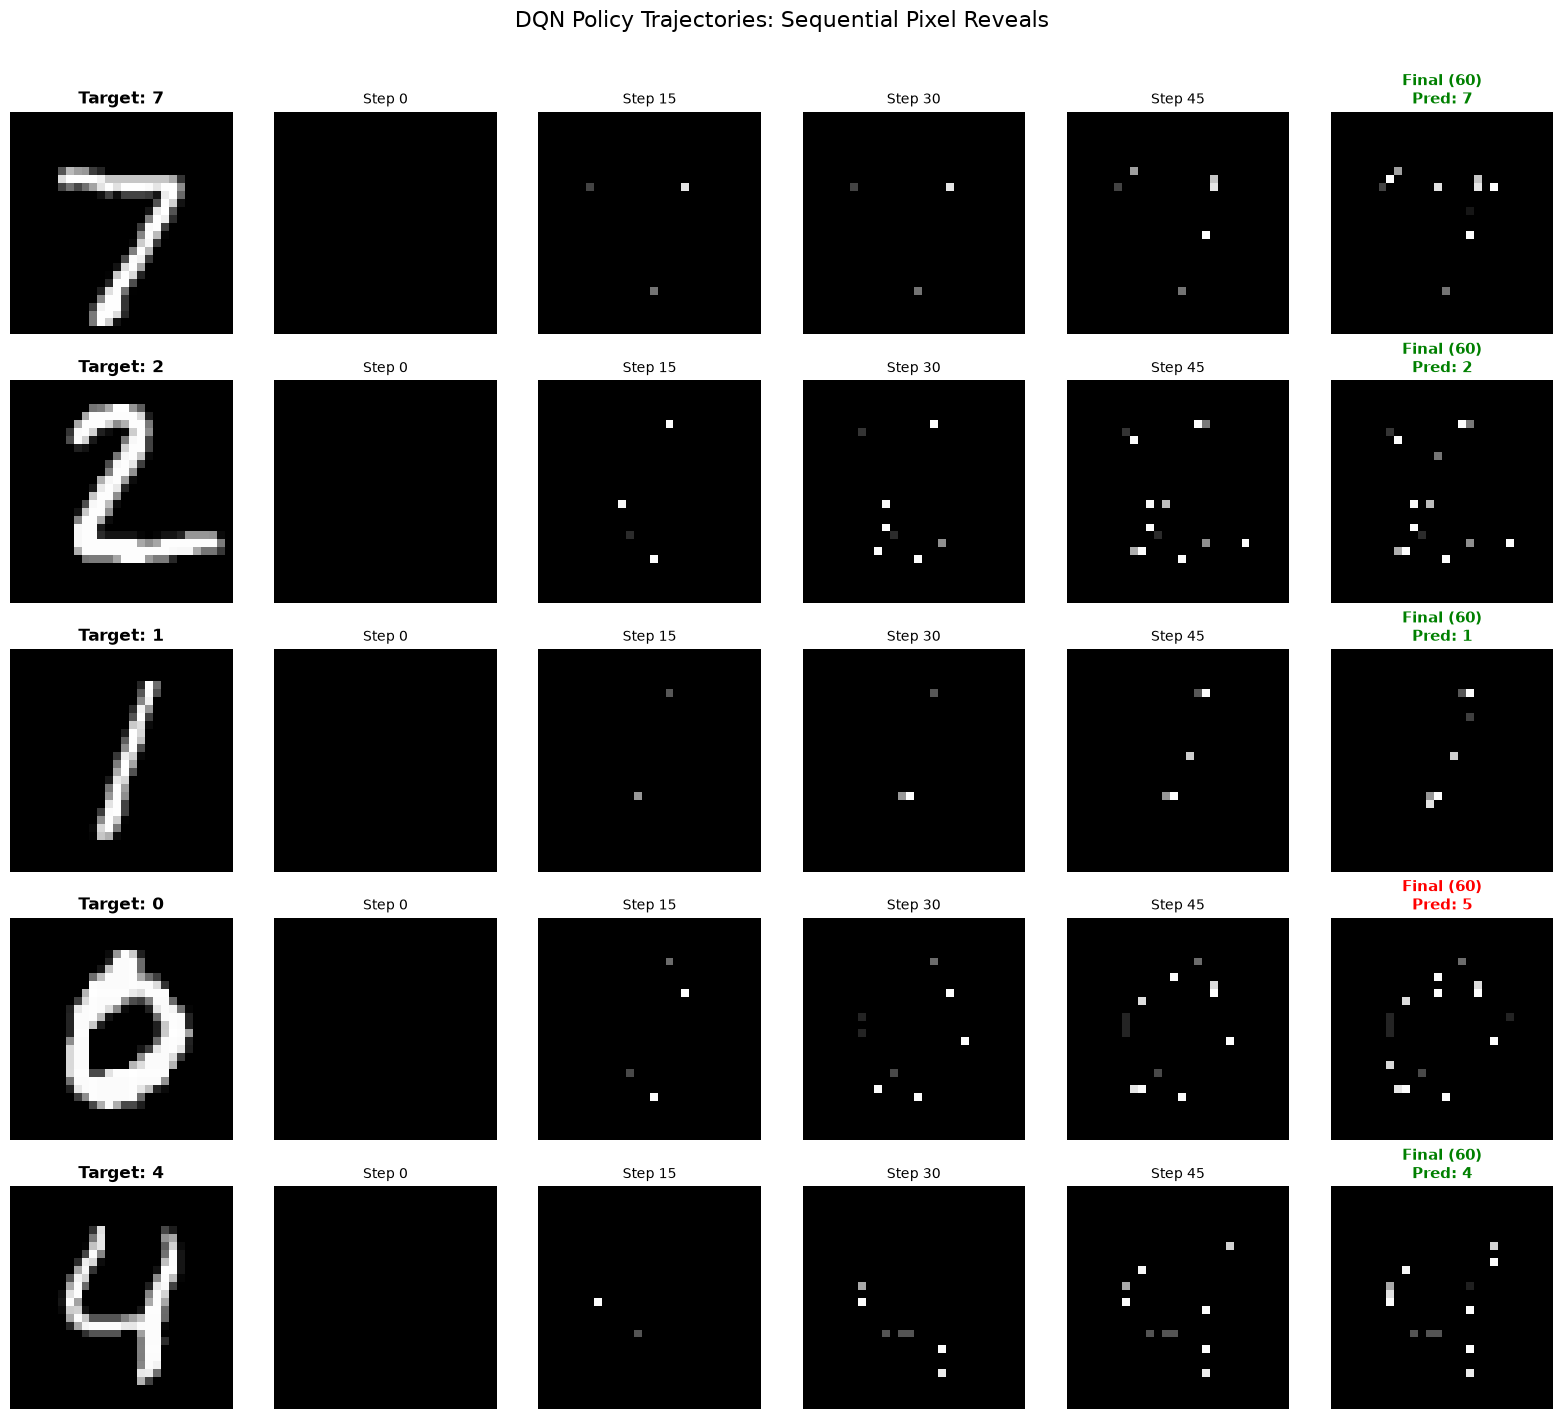

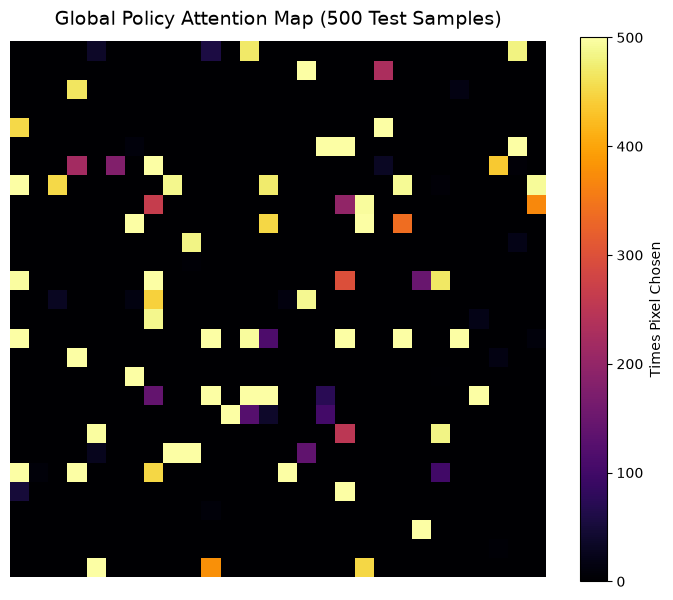

In [ ]:
# %%
import matplotlib.pyplot as plt
import numpy as np
import cupy as cp

def visualize_policy_episodes(network, images, labels, num_samples=5):
    """
    Visualizes step-by-step pixel reveals for a selection of test samples.
    """
    sample_imgs = images[:num_samples]
    sample_lbls = labels[:num_samples]
    
    s = cp.zeros((num_samples, state_size))
    s[:, -1] = 1.0  # budget remaining (normalized)

    # Snapshots to capture during episode
    snapshots = [0, 15, 30, 45, 60]
    history = {snap: None for snap in snapshots}
    history[0] = s[:, :784].copy().reshape(-1, 28, 28)

    # Execute greedy rollout
    for step in range(1, num_pixel_reveals + 1):
        q_values = network.full_forward(s)
        mask_prev_actions = s[:, 784:-1].astype(bool)
        greedy_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, q_values), axis=1)
        
        s = reveal_pixel(s, greedy_actions, sample_imgs)
        if step == num_pixel_reveals:
            s[:, -1] = -1.0
        
        if step in history:
            history[step] = s[:, :784].copy().reshape(-1, 28, 28)

    # Run classifier on final revealed state
    out = s[:, :784]
    for layer in pretrained_classifier:
        out = layer.forward(out)
    preds = cp.argmax(out, axis=1)

    # Plot trajectories
    fig, axes = plt.subplots(num_samples, len(snapshots) + 1, figsize=(16, 2.8 * num_samples))
    
    for i in range(num_samples):
        true_lbl = int(sample_lbls[i].get() if hasattr(sample_lbls[i], 'get') else sample_lbls[i])
        pred_lbl = int(preds[i].get() if hasattr(preds[i], 'get') else preds[i])
        
        # Original Image
        axes[i, 0].imshow(sample_imgs[i].get().reshape(28, 28), cmap='gray')
        axes[i, 0].set_title(f"Target: {true_lbl}", fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Intermediate step progress
        for j, snap in enumerate(snapshots):
            img_snap = history[snap][i].get()
            ax = axes[i, j + 1]
            ax.imshow(img_snap, cmap='gray', vmin=0, vmax=1)
            
            if snap == num_pixel_reveals:
                color = 'green' if true_lbl == pred_lbl else 'red'
                ax.set_title(f"Final ({snap})\nPred: {pred_lbl}", fontsize=11, fontweight='bold', color=color)
            else:
                ax.set_title(f"Step {snap}", fontsize=10)
            ax.axis('off')

    plt.suptitle("DQN Policy Trajectories: Sequential Pixel Reveals", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


def visualize_global_policy_attention(network, images, num_samples=500):
    """
    Computes and plots a 2D spatial heatmap showing pixel selection frequency across samples.
    """
    subset_imgs = images[:num_samples]
    s = cp.zeros((num_samples, state_size))
    s[:, -1] = 1.0

    selection_counts = cp.zeros(784)

    for step in range(num_pixel_reveals):
        q_values = network.full_forward(s)
        mask_prev_actions = s[:, 784:-1].astype(bool)
        greedy_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, q_values), axis=1)
        
        # Aggregate selected actions
        uniques, counts = cp.unique(greedy_actions, return_counts=True)
        selection_counts[uniques] += counts

        s = reveal_pixel(s, greedy_actions, subset_imgs)

    heatmap = selection_counts.get().reshape(28, 28)

    plt.figure(figsize=(7, 6))
    plt.imshow(heatmap, cmap='inferno', interpolation='nearest')
    plt.colorbar(label='Times Pixel Chosen')
    plt.title(f"Global Policy Attention Map ({num_samples} Test Samples)", fontsize=14, pad=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Run Visualizations ---
visualize_policy_episodes(online_network, x_test, y_test, num_samples=5)
visualize_global_policy_attention(online_network, x_test, num_samples=500)

Executing greedy rollout for 60 steps on 5 samples...
Generating visualization...


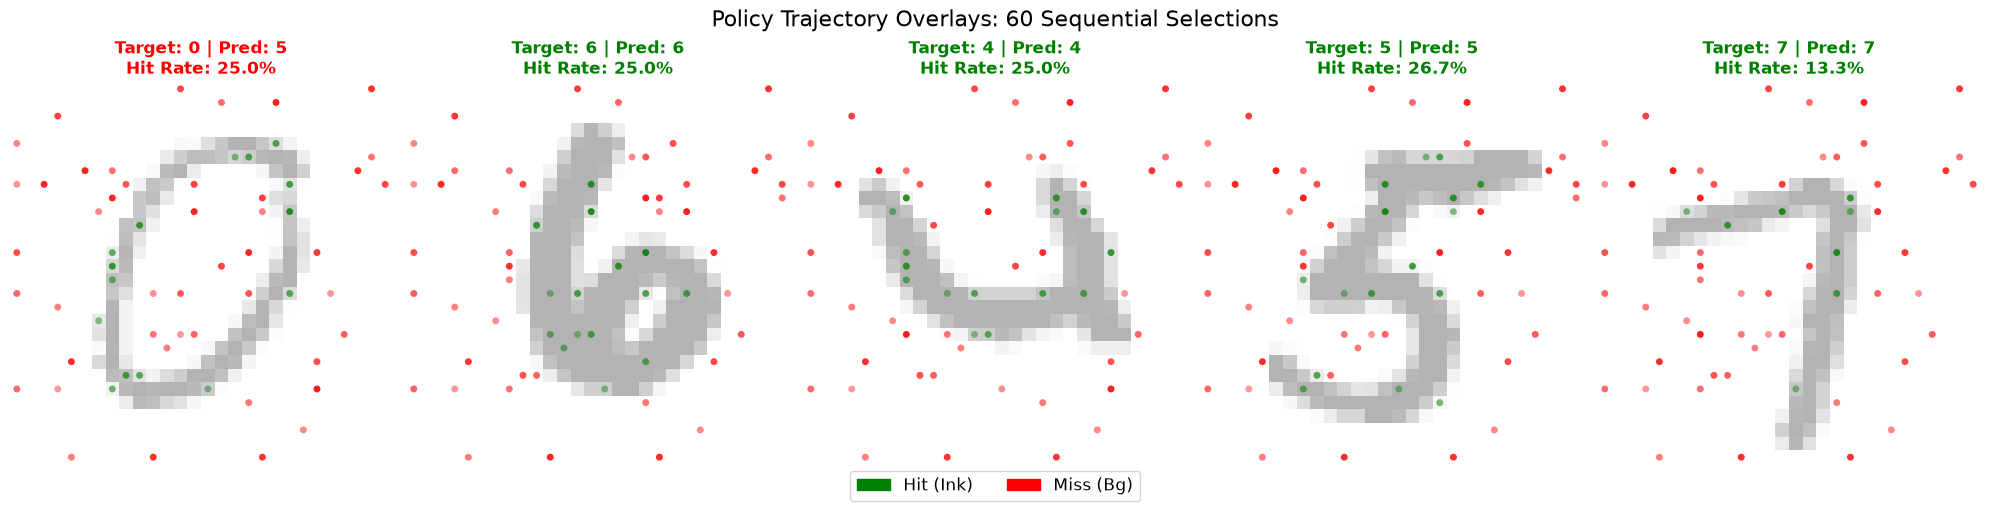

In [ ]:
# %%
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cupy as cp

def visualize_hit_miss_overlays(network, images, labels, num_samples=5, ink_threshold=0.1):
    """
    Visualizes the full trajectory of 60 selections overlaid on the ground truth image.
    Uses Green for Hits (ink) and Red for Misses (background).
    """
    # 1. Select distinct samples from test set
    indices = cp.asarray(rng.choice(images.shape[0], size=num_samples, replace=False))
    sample_imgs = images[indices] # Cupy array
    sample_lbls = labels[indices] # Cupy array
    
    # 2. Setup greedy simulation state
    batch_size = num_samples
    s = cp.zeros((batch_size, state_size))
    s[:, -1] = 1.0  # budget remaining (normalized)

    # 3. Track actions and hit/miss status
    # History stored as lists on CPU for easier plotting
    actions_taken = [[] for _ in range(batch_size)]
    hit_status = [[] for _ in range(batch_size)]

    # 4. Execute greedy rollout for 60 steps
    print(f"Executing greedy rollout for {num_pixel_reveals} steps on {num_samples} samples...")
    for step in range(num_pixel_reveals):
        q_values = network.full_forward(s)
        
        # Mask previously revealed actions
        mask_prev_actions = s[:, 784:-1].astype(bool)
        greedy_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, q_values), axis=1)
        
        # Convert actions to numpy for tracking
        actions_np = greedy_actions.get()
        
        # Determine hits vs misses based on ground truth image
        for i in range(batch_size):
            action_idx = int(actions_np[i])
            original_value = float(sample_imgs[i, action_idx].get())
            is_hit = original_value > ink_threshold
            
            actions_taken[i].append(action_idx)
            hit_status[i].append(is_hit)

        # Environment step to get next state representation
        s_prime = reveal_pixel(s, greedy_actions, sample_imgs)
        # Handle terminal step logic (budget -> -1) needed for full forward pass consistency
        if step == num_pixel_reveals - 1:
            s_prime[:, -1] = -1.0
        s = s_prime

    # 5. Run classifier on final state for prediction
    out = s[:, :784]
    for layer in pretrained_classifier:
        out = layer.forward(out)
    preds = cp.argmax(out, axis=1).get()

    # 6. Setup Plotting
    print("Generating visualization...")
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 5))
    
    # Ensure axes is iterable even if num_samples=1
    if num_samples == 1: axes = [axes]

    for i in range(num_samples):
        ax = axes[i]
        true_lbl = int(sample_lbls[i].get())
        pred_lbl = int(preds[i])
        
        # A. Show the ground truth image faintly in the background
        # We use 'gist_gray_r' (reversed) so background is white and digit is light gray
        true_img_2d = sample_imgs[i].get().reshape(28, 28)
        ax.imshow(true_img_2d, cmap='gist_gray_r', alpha=0.3, interpolation='nearest')
        
        # B. Plot the trajectory of selections
        total_hits = 0
        for step_idx, action_idx in enumerate(actions_taken[i]):
            # Convert flattened index to (x, y) coordinates for scattering
            # y = row (0 is top), x = column
            y = action_idx // 28
            x = action_idx % 28
            
            # Determine color and size
            is_hit = hit_status[i][step_idx]
            color = 'green' if is_hit else 'red'
            
            if is_hit: total_hits += 1
            
            # Scatter plot point (note: scatter uses x, y Cartesian, matching imshow pixel coords)
            # We fade older points slightly using alpha based on step_idx
            alpha = np.interp(step_idx, [0, num_pixel_reveals], [0.4, 0.9])
            ax.scatter(x, y, c=color, s=25, marker='o', edgecolors='none', alpha=alpha)

        # C. Formatting
        hit_rate = (total_hits / num_pixel_reveals) * 100
        title_color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f"Target: {true_lbl} | Pred: {pred_lbl}\nHit Rate: {hit_rate:.1f}%", 
                     color=title_color, fontsize=12, fontweight='bold')
        ax.set_xlim(-0.5, 27.5)
        ax.set_ylim(27.5, -0.5) # Invert y-axis to match image coordinates
        ax.axis('off')

    # D. Legend
    green_patch = mpatches.Patch(color='green', label='Hit (Ink)')
    red_patch = mpatches.Patch(color='red', label='Miss (Bg)')
    fig.legend(handles=[green_patch, red_patch], loc='lower center', 
               ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.02))

    plt.suptitle(f"Policy Trajectory Overlays: {num_pixel_reveals} Sequential Selections", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 0.98]) # Adjust layout to make room for legend
    plt.show()

# --- Run Visualization ---
visualize_hit_miss_overlays(online_network, x_test, y_test, num_samples=5, ink_threshold=0.1)

In [ ]:
# %%
def evaluate_random_policy(images, labels, batch_size=256):
    """
    Evaluates a completely random policy that selects uniform unrevealed pixels.
    Returns the classification accuracy as a percentage.
    """
    num_samples = images.shape[0]
    total_correct = 0.0

    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_images = images[start_idx:end_idx]
        batch_labels = labels[start_idx:end_idx]
        curr_batch_size = batch_images.shape[0]

        # Initialize state
        s = cp.zeros((curr_batch_size, state_size))
        s[:, -1] = 1.0  # budget remaining (normalized)

        # Execute 60 random pixel reveals
        for pixel_reveals_left in range(num_pixel_reveals, 0, -1):
            # Mask previously revealed actions so we don't re-select them
            mask_prev_actions = s[:, 784:-1].astype(bool)
            
            # Draw random noise and mask out invalid actions with -inf
            random_noise = cp.asarray(rng.random((curr_batch_size, 784)))
            random_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, random_noise), axis=1)

            # Environment step
            s_prime = reveal_pixel(s, random_actions, batch_images)

            if pixel_reveals_left == 1:
                s_prime[:, -1] = -1.0

            s = s_prime

        # Measure accuracy with frozen classifier
        _, batch_accuracy = get_reward(s, batch_labels)
        total_correct += float(batch_accuracy) * curr_batch_size

    return (total_correct / num_samples) * 100.0

# --- Run Random Baseline Evaluation ---
print("Evaluating Random Baseline Policy on Test Set...")
random_test_acc = evaluate_random_policy(x_test, y_test, batch_size=256)
dqn_test_acc = evaluate_policy(online_network, x_test, y_test, batch_size=256)

print("=" * 45)
print(f"  Random Policy Test Accuracy : {random_test_acc:.2f}%")
print(f"  Trained DQN Policy Test Acc : {dqn_test_acc:.2f}%")
print(f"  DQN Advantage over Random   : +{dqn_test_acc - random_test_acc:.2f}%")
print("=" * 45)

if dqn_test_acc - random_test_acc > 5.0:
    print("Conclusion: Your DQN policy has learned meaningful active-sensing heuristics beyond random guessing!")
else:
    print("Conclusion: Your DQN policy is performing similarly to random pixel selection.")

Evaluating Random Baseline Policy on Test Set...
  Random Policy Test Accuracy : 39.20%
  Trained DQN Policy Test Acc : 65.54%
  DQN Advantage over Random   : +26.34%
Conclusion: Your DQN policy has learned meaningful active-sensing heuristics beyond random guessing!


Executing RANDOM rollout for 60 steps on 5 samples...
Generating visualization...


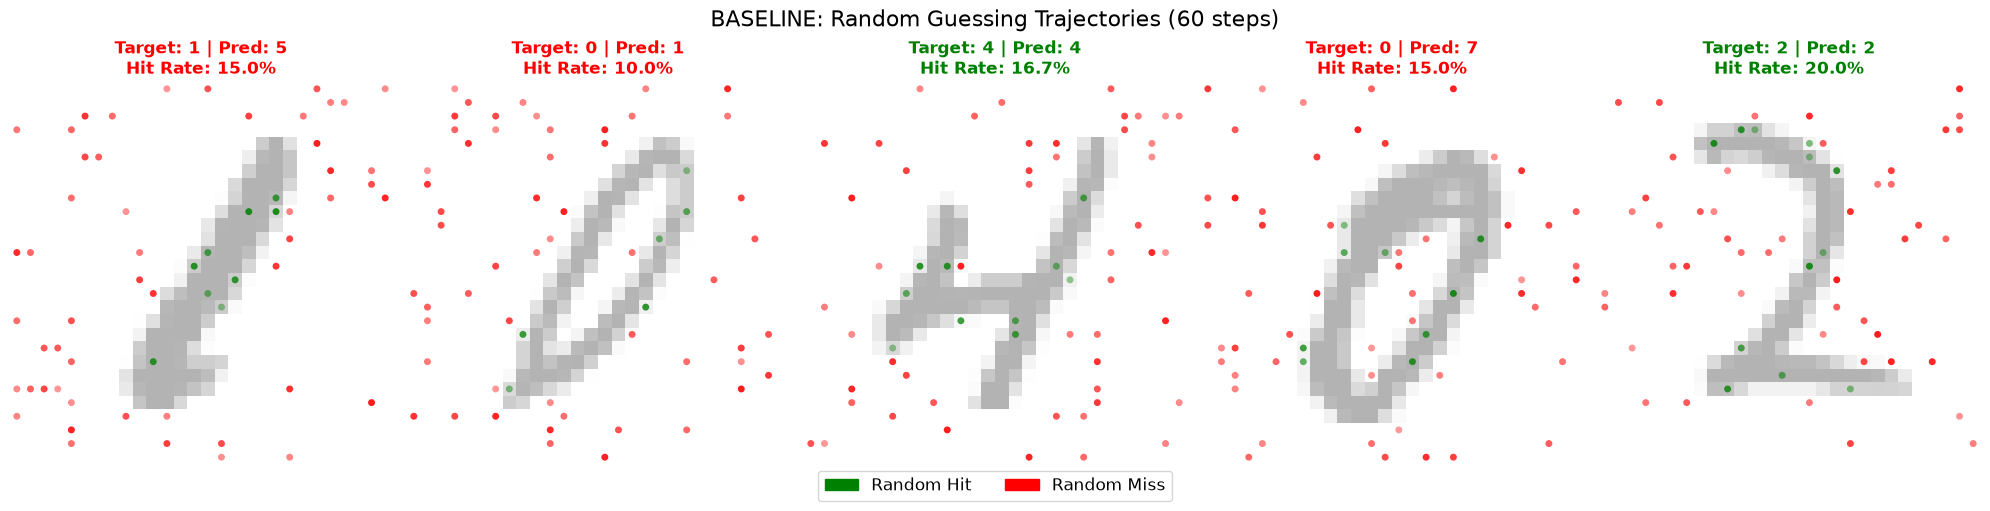

In [ ]:
# %%
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cupy as cp

def visualize_random_policy_trajectories(images, labels, num_samples=5, ink_threshold=0.1):
    """
    Visualizes the full trajectory of 60 completely RANDOM selections.
    Overlaid on the ground truth image faintly in the background.
    Uses Green for Hits (ink) and Red for Misses (background).
    """
    # 1. Select distinct samples from test set
    indices = cp.asarray(rng.choice(images.shape[0], size=num_samples, replace=False))
    sample_imgs = images[indices] # Cupy array
    sample_lbls = labels[indices] # Cupy array
    
    # 2. Setup simulation state
    batch_size = num_samples
    s = cp.zeros((batch_size, state_size))
    s[:, -1] = 1.0  # budget remaining (normalized)

    # 3. Track actions and hit/miss status
    actions_taken = [[] for _ in range(batch_size)]
    hit_status = [[] for _ in range(batch_size)]

    # 4. Execute random rollout for 60 steps
    print(f"Executing RANDOM rollout for {num_pixel_reveals} steps on {num_samples} samples...")
    for step in range(num_pixel_reveals):
        
        # --- Pure Random Action Selection ---
        # Mask previously revealed actions so we don't re-select them
        mask_prev_actions = s[:, 784:-1].astype(bool)
        
        # Draw random noise and mask out invalid actions with -inf
        random_noise = cp.asarray(rng.random((batch_size, 784)))
        random_actions = cp.argmax(cp.where(mask_prev_actions, -cp.inf, random_noise), axis=1)
        # -------------------------------------

        # Convert actions to numpy for tracking
        actions_np = random_actions.get()
        
        # Determine hits vs misses based on ground truth image
        for i in range(batch_size):
            action_idx = int(actions_np[i])
            original_value = float(sample_imgs[i, action_idx].get())
            is_hit = original_value > ink_threshold
            
            actions_taken[i].append(action_idx)
            hit_status[i].append(is_hit)

        # Environment step to get next state representation
        s_prime = reveal_pixel(s, random_actions, sample_imgs)
        
        # Handle terminal step logic (budget -> -1)
        if step == num_pixel_reveals - 1:
            s_prime[:, -1] = -1.0
        s = s_prime

    # 5. Run classification on the final state resulting from random guesses
    out = s[:, :784]
    for layer in pretrained_classifier:
        out = layer.forward(out)
    preds = cp.argmax(out, axis=1).get()

    # 6. Setup Plotting
    print("Generating visualization...")
    fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 5))
    
    if num_samples == 1: axes = [axes]

    for i in range(num_samples):
        ax = axes[i]
        true_lbl = int(sample_lbls[i].get())
        pred_lbl = int(preds[i])
        
        # A. Show the ground truth image faintly in the background ('gis_gray_r' inverted)
        true_img_2d = sample_imgs[i].get().reshape(28, 28)
        ax.imshow(true_img_2d, cmap='gist_gray_r', alpha=0.3, interpolation='nearest')
        
        # B. Plot the trajectory of selections
        total_hits = 0
        for step_idx, action_idx in enumerate(actions_taken[i]):
            y = action_idx // 28
            x = action_idx % 28
            
            # Determine color
            is_hit = hit_status[i][step_idx]
            color = 'green' if is_hit else 'red'
            if is_hit: total_hits += 1
            
            # Fade older points slightly
            alpha = np.interp(step_idx, [0, num_pixel_reveals], [0.4, 0.9])
            ax.scatter(x, y, c=color, s=25, marker='o', edgecolors='none', alpha=alpha)

        # C. Formatting
        hit_rate = (total_hits / num_pixel_reveals) * 100
        # Color title based on if classifier guessed correctly with this random info
        title_color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f"Target: {true_lbl} | Pred: {pred_lbl}\nHit Rate: {hit_rate:.1f}%", 
                     color=title_color, fontsize=12, fontweight='bold')
        ax.set_xlim(-0.5, 27.5)
        ax.set_ylim(27.5, -0.5) # Invert y-axis
        ax.axis('off')

    # D. Legend
    green_patch = mpatches.Patch(color='green', label='Random Hit')
    red_patch = mpatches.Patch(color='red', label='Random Miss')
    fig.legend(handles=[green_patch, red_patch], loc='lower center', 
               ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.02))

    plt.suptitle(f"BASELINE: Random Guessing Trajectories ({num_pixel_reveals} steps)", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()

# --- Run Visualization ---
# Using same threshold as DQN visualization for fair comparison
visualize_random_policy_trajectories(x_test, y_test, num_samples=5, ink_threshold=0.1)